# Differential CpG methylation

This notebook identifies differentially CpG-methylated regions (DMRs) between MeD-seq samples.

## Input

- CpG methylation labels per region, available from GEO (GSE304236_CpG.regions.txt)

## Output

- Figure 5a. Correlation heatmap of promoter CpG levels
- Figure 5b-c: MA plots of DMRs
- Figure 5d-e: Barplot of DMR regions
- Figure S10a-b. Volcano plot of promoter DMRs
- Tables S6 and S7. DMRs between iPSC and DE, and between DE and PGT

## Packages

In [1]:
# General
from pathlib import Path
import numpy as np
import pandas as pd

# Plotting
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Statistics
import scipy
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

# Rpy2
%load_ext rpy2.ipython

# Plot settings
plt.rcParams.update({"figure.figsize": (10, 10), "svg.fonttype": "none", "font.family": "Arial"})
sns.set_style("ticks")

In [2]:
# Directories: update these paths as needed
input_dir = "../Input/GEO"   # folder where GEO data is stored
output_dir = "../Output"    # folder where output files will be saved
Path(output_dir).mkdir(parents=True, exist_ok=True)

# Settings
labels = ["iPSC", "DE", "PGT"]              # custom labels
colors = ["#264653", "#E9C46A", "#E76F51"]  # colors to use
palette = dict(zip(labels, colors))         # palette for plots

comparisons = ["iPSC_DE", "DE_PGT"]
comparison_colors = [["#264653", "#E9C46A"], ["#E9C46A", "#E76F51"]]

## Figure 5a. Correlation heatmap of promoter CpG levels

In [3]:
counts_gene = pd.read_csv(f"{input_dir}/GSE304236_CpG.regions.txt", sep="\t", index_col=0)
counts_gene = counts_gene[counts_gene["NrSites"] > 10]

counts_promoter = counts_gene[counts_gene["Region"] == "Promoter"]
counts_promoter = counts_promoter.drop(["NrSites", "GeneName", "GeneID", "Region"], axis=1)
display(counts_promoter)

,C4neg-1,C4neg-2,C4neg-3,C4-1,C4-2,C4-3,DE-c1,DE-c2,DE-c3,DE-d1,DE-d2,DE-d3,PGT-c1,PGT-c2,PGT-c3
Promoter.ENSG00000000003,0,4,2,4,3,1,4,4,7,8,8,3,8,4,12
Promoter.ENSG00000000460,0,4,6,2,2,4,4,0,5,0,7,3,0,0,1
Promoter.ENSG00000000971,7,1,2,0,0,11,9,7,6,7,2,5,5,6,1
Promoter.ENSG00000001167,17,14,9,7,15,20,21,15,35,24,27,8,45,62,49
Promoter.ENSG00000001460,96,97,64,36,72,89,88,102,85,81,65,94,70,114,95
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Promoter.ENSG00000291258,202,88,135,105,94,96,127,146,132,90,118,83,221,201,152
Promoter.ENSG00000291259,77,40,50,48,52,35,53,75,90,64,71,44,87,90,94
Promoter.ENSG00000291270,239,82,94,91,96,65,115,112,117,59,118,73,171,179,163
Promoter.ENSG00000291280,473,226,256,242,218,166,349,384,302,229,279,247,391,318,352


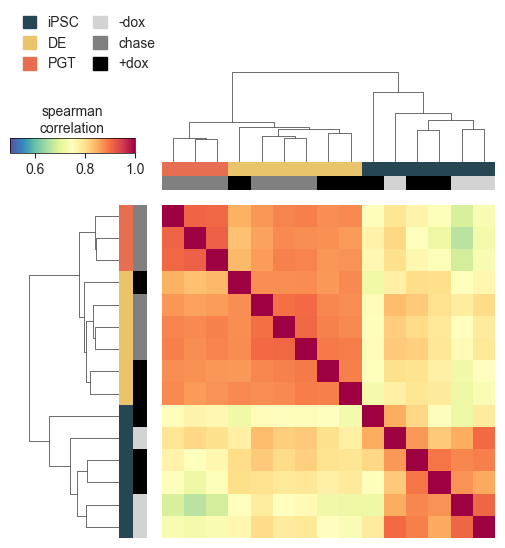

In [4]:
# Calculate correlation
mostvar = counts_promoter.var(axis=1).nlargest(1500).index
counts_mostvar = counts_promoter.loc[mostvar]
corr = counts_mostvar.corr(method="spearman")

# Sample annotation
anno = [[palette["iPSC"]]*6 + [palette["DE"]]*6 + [palette["PGT"]]*3,
                               ["lightgray"]*3 + ["black"]*3 + ["gray"]*3 + ["black"]*3 + ["gray"]*3,
                               ["white"]*len(corr.columns.tolist())]

# Heatmap
g = sns.clustermap(corr, cmap="Spectral_r", figsize=(5,5), dendrogram_ratio=(0.2,0.2), annot=False,
                   row_colors=anno, col_colors=anno, xticklabels=False, yticklabels=False, vmin=0.5, vmax=1,
                   cbar_kws={"shrink": .8, "label": "spearman\ncorrelation", "orientation": "horizontal"})

# Annotation legend
plt.legend(handles=[matplotlib.patches.Patch(color=palette["iPSC"], label="iPSC"), 
                    matplotlib.patches.Patch(color=palette["DE"], label="DE"), 
                    matplotlib.patches.Patch(color=palette["PGT"], label="PGT"), 
                    matplotlib.patches.Patch(color="lightgray", label="-dox"), 
                    matplotlib.patches.Patch(color="gray", label="chase"), 
                    matplotlib.patches.Patch(color="black", label="+dox")], 
           loc="upper left", bbox_to_anchor=(0, 10), frameon=False, handleheight=1, handlelength=1, ncol=2, columnspacing=1)

# Edit colorbar
g.cax.set_position([0, 0.8, 0.25, 0.03])
g.cax.xaxis.set_label_position("top")
for spine in g.cax.spines.values():
    spine.set_edgecolor("black")
    spine.set_linewidth(0.5)

plt.savefig(f"{output_dir}/Figure5a.svg", format="svg")
plt.show()

## DESeq2

In [5]:
%%R

# Set library path where packages are installed
.libPaths(c(file.path(Sys.getenv("CONDA_PREFIX"), "lib/R/library"), .libPaths()))
.libPaths()

# Load packages
packages <- c("DESeq2", "BiocParallel")
suppressMessages(invisible(lapply(packages, library, character.only = TRUE)))

# Set number of cores and memory to use
register(MulticoreParam(4))
options(future.globals.maxSize = 60000 * 1024^2, future.seed=42)
set.seed(42)

# List loaded packages
sessionInfo()

R version 4.4.0 (2024-04-24)
Platform: x86_64-conda-linux-gnu
Running under: Linux Mint 21.3

Matrix products: default
BLAS/LAPACK: /home/beatrice/miniconda3/envs/hDCM-TM/lib/libopenblasp-r0.3.25.so;  LAPACK version 3.11.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=nl_NL.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=nl_NL.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=nl_NL.UTF-8 LC_IDENTIFICATION=C       

time zone: Europe/Amsterdam
tzcode source: system (glibc)

attached base packages:
[1] stats4    tools     stats     graphics  grDevices utils     datasets 
[8] methods   base     

other attached packages:
 [1] BiocParallel_1.40.0         DESeq2_1.46.0              
 [3] SummarizedExperiment_1.36.0 Biobase_2.66.0             
 [5] MatrixGenerics_1.18.0       matrixStats_1.5.0          
 [7] GenomicRanges_1.58

In addition: There were 11 warnings (use warnings() to see them)


In [6]:
# Prepare input for DESeq2
counts_deseq = counts_gene.copy()
counts_deseq = counts_deseq.drop(["NrSites", "GeneName", "GeneID", "Region"], axis=1)

samples = [sample.replace("-", "no").replace("+", "").replace(" ", ".") for sample in counts_deseq.columns.tolist()]
meta = pd.DataFrame(index=samples)
meta["Celltype"] = ["iPSC"]*6 + ["DE"]*6 + ["PGT"]*3
display(meta)

counts_deseq.columns = samples
display(counts_deseq)

# Input iPSC vs DE
meta_ipsc_de = meta[meta["Celltype"].isin(["iPSC", "DE"])]
counts_ipsc_de = counts_deseq[meta_ipsc_de.index]

# Input DE vs PGT
meta_de_pgt = meta[meta["Celltype"].isin(["DE", "PGT"])]
counts_de_pgt = counts_deseq[meta_de_pgt.index]

,Celltype
C4negno1,iPSC
C4negno2,iPSC
C4negno3,iPSC
C4no1,iPSC
C4no2,iPSC
C4no3,iPSC
DEnoc1,DE
DEnoc2,DE
DEnoc3,DE
DEnod1,DE


,C4negno1,C4negno2,C4negno3,C4no1,C4no2,C4no3,DEnoc1,DEnoc2,DEnoc3,DEnod1,DEnod2,DEnod3,PGTnoc1,PGTnoc2,PGTnoc3
GeneBody.ENSG00000000003,125,103,105,41,115,116,66,69,83,67,74,113,89,79,88
GeneBody.ENSG00000000005,42,39,59,15,61,56,37,35,64,40,52,56,43,59,33
GeneBody.ENSG00000000419,98,75,75,22,74,67,102,112,74,68,79,98,77,74,104
GeneBody.ENSG00000000460,978,774,1163,277,703,689,802,877,893,687,660,607,885,982,836
GeneBody.ENSG00000000971,733,490,767,154,468,539,566,509,623,454,472,434,629,629,619
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Y.268139.271338,229,114,158,183,87,54,90,102,135,73,71,64,109,134,115
Y.273003.274629,202,97,98,110,118,59,140,135,144,99,106,87,199,134,166
Y.2886148.2889977,18,25,10,2,8,15,12,12,13,4,1,12,4,8,4
Y.4356284.4358812,25,17,13,4,11,25,8,12,12,17,11,13,17,13,10



out of 74223 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 12330, 17%
LFC < 0 (down)     : 5931, 8%
outliers [1]       : 19, 0.026%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



estimating size factors
estimating dispersions
gene-wise dispersion estimates: 4 workers
mean-dispersion relationship
final dispersion estimates, fitting model and testing: 4 workers
using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041


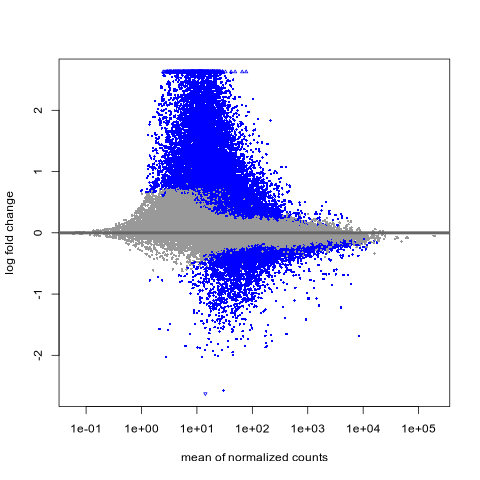

In [7]:
%%R -i meta_ipsc_de -i counts_ipsc_de -o iPSC_DE

# Create DESeq2 dataset
meta_ipsc_de$Celltype <- factor(meta_ipsc_de$Celltype, levels = c("iPSC", "DE"))
dds <- DESeqDataSetFromMatrix(countData = counts_ipsc_de, colData = meta_ipsc_de, design = ~Celltype)
dds <- DESeq(dds, fitType="local", parallel=TRUE, betaPrior=FALSE)
dds

# Differential test
res_diff <- results(dds, contrast=c("Celltype", "DE", "iPSC"), alpha=0.05, independentFiltering = FALSE)
res_diff <- lfcShrink(dds, contrast=c("Celltype", "DE", "iPSC"), res=res_diff, type="ashr")

summary(res_diff)
plotMA(res_diff)

iPSC_DE <- as.data.frame(res_diff)


out of 74227 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 4849, 6.5%
LFC < 0 (down)     : 2184, 2.9%
outliers [1]       : 11, 0.015%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



estimating size factors
estimating dispersions
gene-wise dispersion estimates: 4 workers
mean-dispersion relationship
final dispersion estimates, fitting model and testing: 4 workers
using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041


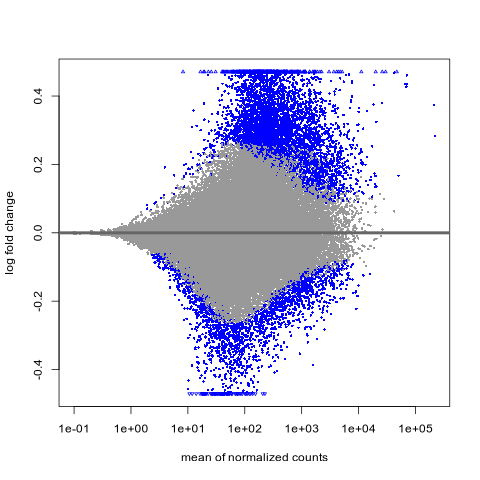

In [8]:
%%R -i meta_de_pgt -i counts_de_pgt -o DE_PGT

# Create DESeq2 dataset
meta_de_pgt$Celltype <- factor(meta_de_pgt$Celltype, levels = c("DE", "PGT"))
dds <- DESeqDataSetFromMatrix(countData = counts_de_pgt, colData = meta_de_pgt, design = ~Celltype)
dds <- DESeq(dds, fitType="local", parallel=TRUE, betaPrior=FALSE)
dds

# Differential test
res_diff <- results(dds, contrast=c("Celltype", "PGT", "DE"), alpha=0.05, independentFiltering = FALSE)
res_diff <- lfcShrink(dds, contrast=c("Celltype", "PGT", "DE"), res=res_diff, type="ashr")

summary(res_diff)
plotMA(res_diff)

DE_PGT <- as.data.frame(res_diff)

## Figure 5b-c: MA plots of DMRs

In [9]:
de_dfs = []
comparisons = [["iPSC", "DE"], ["DE", "PGT"]]

for i, de_df in enumerate([iPSC_DE, DE_PGT]):
    de_df = de_df.sort_values(by="padj")
    x, y = comparisons[i]
    de_df["Category"] = np.select([(de_df["padj"] < 0.05) & (de_df["log2FoldChange"] > 0.25), 
                                   (de_df["padj"] < 0.05) & (de_df["log2FoldChange"] < -0.25)], [y, x], default="Not significant")
    
    de_df["-log10(adjusted P-value)"] = de_df["padj"].apply(lambda x: -np.log10(x) if x > 0 else 0)
    de_df["LogBaseMean"] = np.log10(de_df["baseMean"] + 0.001)
    max_value = de_df["-log10(adjusted P-value)"].replace([np.inf], np.nan).max()
    de_df["-log10(adjusted P-value)"] = de_df["-log10(adjusted P-value)"].replace([np.inf], max_value)
    de_df.dropna(inplace=True)
    de_df = pd.merge(de_df, counts_gene, left_index=True, right_index=True)
    display(de_df[["Category"]])

    de_dfs.append(de_df)

,Category
4.6105403.6105910,DE
3.164333100.164342041,iPSC
9.78853643.78860095,iPSC
12.114674209.114674822,DE
17.7853254.7854334,DE
...,...
12.22717719.22745438,Not significant
2.236705129.236707557,Not significant
GeneBody.ENSG00000116824,Not significant
6.32664381.32665250,Not significant


,Category
GeneBody.ENSG00000115507,PGT
22.39487510.39489005,PGT
GeneBody.ENSG00000101076,DE
Promoter.ENSG00000148396,DE
GeneBody.ENSG00000170561,PGT
...,...
GeneBody.ENSG00000261738,Not significant
GeneBody.ENSG00000259823,Not significant
GeneBody.ENSG00000112214,Not significant
Promoter.ENSG00000290538,Not significant


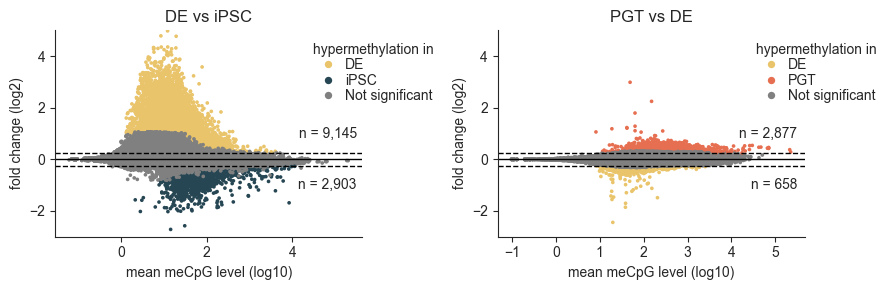

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3))

for i, de_df in enumerate(de_dfs):
    x, y = comparisons[i]

    # Filter non-significant dots for editing
    mask = (de_df["Category"] == "Not significant") & (de_df["LogBaseMean"].between(-0.5, 3.5))
    df_dense = de_df[mask].copy()
    df_others = de_df[~mask].copy()
    df_dense["LogBaseMean_temp"] = df_dense["LogBaseMean"].round(2)
    df_dense["log2FoldChange_temp"] = df_dense["log2FoldChange"].round(2)
    df_dense = df_dense.drop_duplicates(subset=["LogBaseMean_temp", "log2FoldChange_temp"])
    plot_df = pd.concat([df_dense, df_others]).reset_index(drop=True)

    # MA plots
    volcano_palette = {x: palette[x.split(".")[0]], y: palette[y.split(".")[0]], "Not significant": "gray"}
    sns.scatterplot(data=plot_df[::-1], x="LogBaseMean", y="log2FoldChange", hue="Category",
                    marker="o", s=7, linewidth=0, legend=True, palette=volcano_palette, ax=axes[i])

    # Add axis labels and threshold lines
    axes[i].set(title=f"{y} vs {x}", ylabel="fold change (log2)", xlabel="mean meCpG level (log10)", ylim=(-3, 5))
    axes[i].axhline(0.25, color="black", linestyle="--", linewidth=1)
    axes[i].axhline(0, color="black", linestyle="-", linewidth=1)
    axes[i].axhline(-0.25, color="black", linestyle="--", linewidth=1)

    # Add number of DMRs
    nr_up = len(de_df[de_df["Category"] == y])
    nr_down = len(de_df[de_df["Category"] == x])
    axes[i].text(5.5, 1, f"n = {nr_up:,}", ha="right", va="center")
    axes[i].text(5.5, -1, f"n = {nr_down:,}", ha="right", va="center")
    
    # Add legend
    handles, labels = axes[i].get_legend_handles_labels()
    labels = [label.replace(".", " ") for label in labels]
    axes[i].legend(handles[::-1], labels[::-1], loc="upper left", bbox_to_anchor=(0.8, 1), 
                   title="hypermethylation in", frameon=False, markerscale=2, handletextpad=0.2, labelspacing=0.1)

sns.despine()
plt.tight_layout()
plt.savefig(f"{output_dir}/Figure5bc.svg", format="svg")
plt.show()

## Figure 5d-e: Barplot of DMR regions

,Region,Direction,Count
0,Promoter,iPSC,2.558005
1,Gene body,iPSC,5.670611
2,CpG island,iPSC,1.017706
3,iPSC enhancer,iPSC,8.000000
4,DE enhancer,iPSC,11.329056
5,Promoter,DE,14.677907
6,Gene body,DE,2.503414
7,CpG island,DE,23.554782
8,iPSC enhancer,DE,3.084337
9,DE enhancer,DE,2.896425


,Region,Direction,Count
0,Promoter,DE,0.979545
1,Gene body,DE,0.986156
2,CpG island,DE,0.597647
3,iPSC enhancer,DE,0.433735
4,DE enhancer,DE,1.741522
5,Promoter,PGT,1.764621
6,Gene body,PGT,2.613313
7,CpG island,PGT,7.103680
8,iPSC enhancer,PGT,1.156627
9,DE enhancer,PGT,0.751604


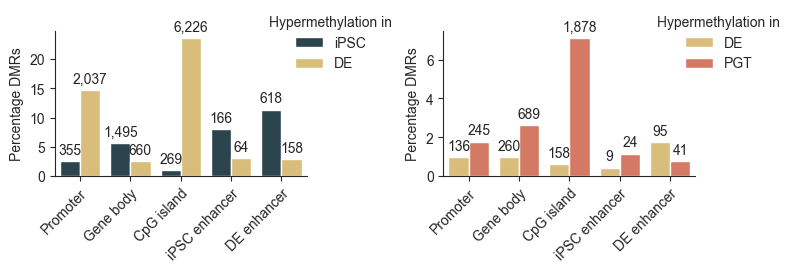

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

for i, de_df in enumerate(de_dfs):
    x, y = comparisons[i]

    # Get numbers per region
    barplot_dict = {}
    total_list = []
    for region in ["Promoter", "GeneBody", "CpGisland", "iPSC enhancer", "DE enhancer"]:
        down = len(de_df[(de_df["Category"] == x) & (de_df["Region"] == region)])
        up = len(de_df[(de_df["Category"] == y) & (de_df["Region"] == region)])
        total = len(de_df[de_df["Region"] == region])
        barplot_dict[region] = [region, down / total * 100, up / total * 100, down, up]
    barplot_df = pd.DataFrame.from_dict(barplot_dict, orient="index", columns=["Region", x, y, f"Nr {x}", f"Nr {y}"])
    up_nrs, down_nrs = barplot_df[f"Nr {x}"], barplot_df[f"Nr {y}"]
    barplot_df = barplot_df.melt(id_vars=["Region"], value_vars=barplot_df.columns.tolist()[1:3], var_name="Direction", value_name="Count")
    barplot_df["Region"] = barplot_df["Region"].str.replace("B", " b").str.replace("CpG", "CpG ")
    display(barplot_df)

    # Barplot
    barplot_palette = {x: palette[x.split(".")[0]], y: palette[y.split(".")[0]]}
    sns.barplot(data=barplot_df, x="Region", y="Count", hue="Direction", palette=barplot_palette, ax=axes[i])

    # Add number of DMRs
    for j, container in enumerate(axes[i].containers):
        labels = up_nrs if j == 0 else down_nrs
        labels = [f"{x:,.0f}" for x in labels]
        axes[i].bar_label(container, labels=labels, padding=3, fontsize=10)

    # Axis labels
    axes[i].set(xlabel="", ylabel="Percentage DMRs")
    plt.setp(axes[i].get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    axes[i].legend(title="Hypermethylation in", frameon=False, bbox_to_anchor=(0.8, 1.2))

sns.despine()
plt.tight_layout()
plt.savefig(f"{output_dir}/Figure5de.svg", format="svg")
plt.show()

## Figure S10a-b. Volcano plot of promoter DMRs

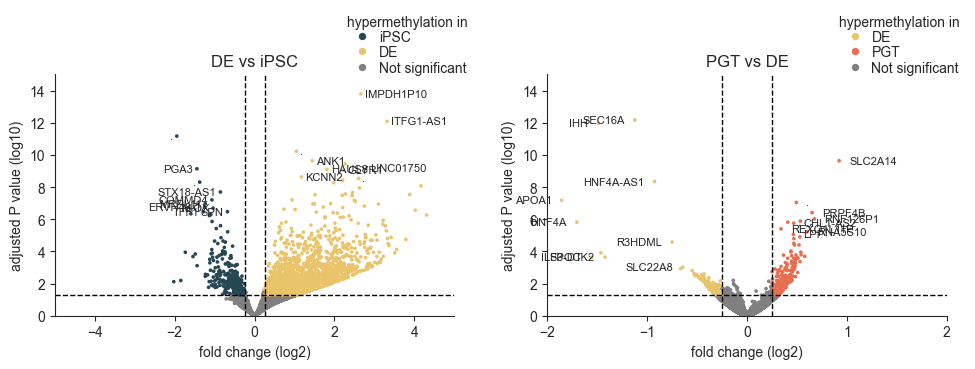

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for i, de_df in enumerate(de_dfs):
    x, y = comparisons[i]
    promoter_df = de_df[de_df["Region"] == "Promoter"]
    
    # Volcano plot
    volcano_palette = {x: palette[x.split(".")[0]], y: palette[y.split(".")[0]], "Not significant": "gray"}
    sns.scatterplot(data=promoter_df[::-1], x="log2FoldChange", y="-log10(adjusted P-value)", hue="Category",
                    marker="o", s=7, linewidth=0, legend=True, palette=volcano_palette, ax=axes[i])

    # Add axis labels and threshold lines
    axes[i].set(title=f"{y} vs {x}", xlabel="fold change (log2)", ylabel="adjusted P value (log10)")
    axes[i].axhline(-np.log10(0.05), color="black", linestyle="--", linewidth=1)
    axes[i].axvline(-0.25, color="black", linestyle="--", linewidth=1)
    axes[i].axvline(0.25, color="black", linestyle="--", linewidth=1)

    # Add labels of top 15 labeled genes
    for _, r in promoter_df[promoter_df["Category"] == x].head(10).iterrows():
        axes[i].text(x=r["log2FoldChange"] - 0.1, y=r["-log10(adjusted P-value)"], s=r["GeneName"], fontsize=8, ha="right", va="center")
    for _, r in promoter_df[promoter_df["Category"] == y].head(10).iterrows():
        axes[i].text(x=r["log2FoldChange"] + 0.1, y=r["-log10(adjusted P-value)"], s=r["GeneName"], fontsize=8, ha="left", va="center")

    # Add legend
    handles, labels = axes[i].get_legend_handles_labels()
    labels = [label.replace(".", " ") for label in labels]
    axes[i].legend(handles[::-1], labels[::-1], loc="upper left", bbox_to_anchor=(0.7, 1.3), 
                   title="hypermethylation in", frameon=False, markerscale=2, handletextpad=0.2, labelspacing=0.1)

axes[0].set(xlim=(-5, 5), ylim=(0, 15))
axes[1].set(xlim=(-2, 2), ylim=(0, 15), xticks=(-2,-1,0,1,2))

sns.despine()
plt.tight_layout()
plt.savefig(f"{output_dir}/SupplementalFigure7b_e.svg", format="svg")
plt.show()

## Tables S6 and S7. DMRs between iPSC and DE, and between DE and PGT

In [13]:
for i, de_df in enumerate(de_dfs):
    sign_df = de_df[de_df["Category"] != "Not significant"]
    sign_df.to_csv(f"{output_dir}/SupplementalTable{6+i}.txt", sep="\t", index=True, header=True)
    de_df.to_csv(f"{output_dir}/DEGs{6+i}.txt", sep="\t", index=True, header=True)